# **Creación de data tabular de la señales fisiológicas obtenidas de EMG y ECG**

In [1]:
#Importación de librerías
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
#Seleccionamos estilo de ploteo
plt.style.use("ggplot")

## Lectura de los datos ECG

In [3]:
#Lectura de documento txt con tabulación (/t) como delimitador
array1 = np.genfromtxt("./señal ecg1.txt", delimiter=",",skip_header = 2)
array2 = np.genfromtxt("./señal ecg2.txt", delimiter=",",skip_header = 2)

In [4]:
#Nos quedamos con el dato del sensor
array1[:,0] = np.arange(0, len(array1[:,0]))
basal1 = array1[500:1500,1]
inhex5s = array1[3500:4500,1]
basal2 = array1[7500:8500,1]

array2[:,0] = np.arange(0, len(array2[:,0]))
reposoburp = array2[1500:3500,1]
inhexburp = array2[36000:38000,1]

## Graficación de los datos ECG

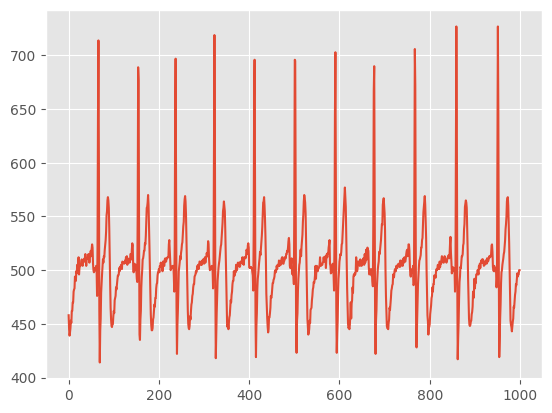

In [5]:
plt.plot(basal1)

## Especificar la Frecuencia de muestreo para medicion ECG 

---



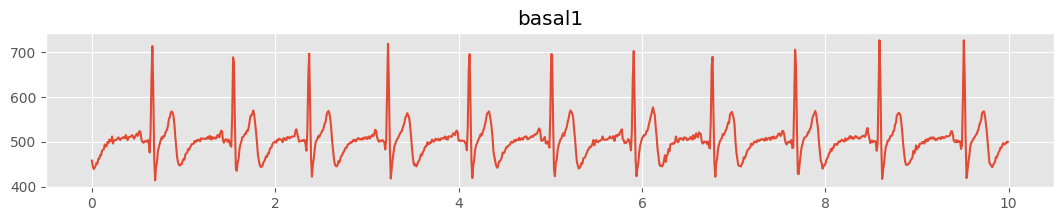

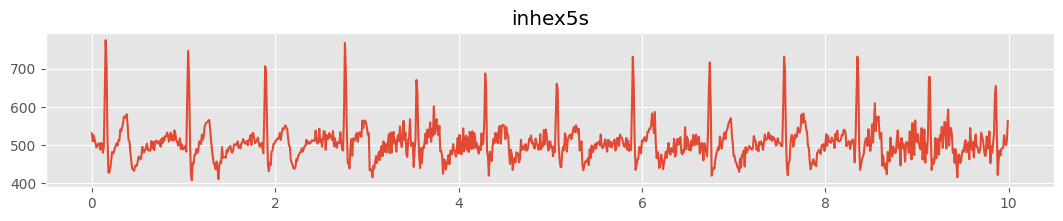

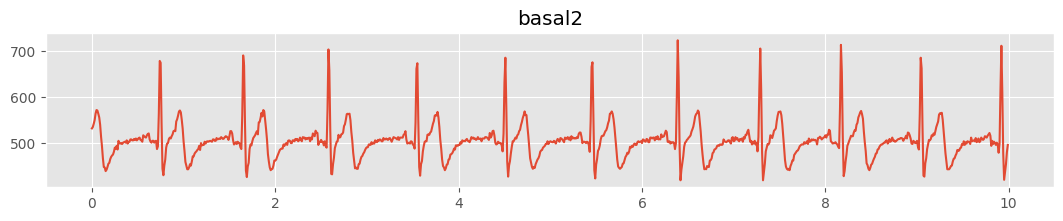

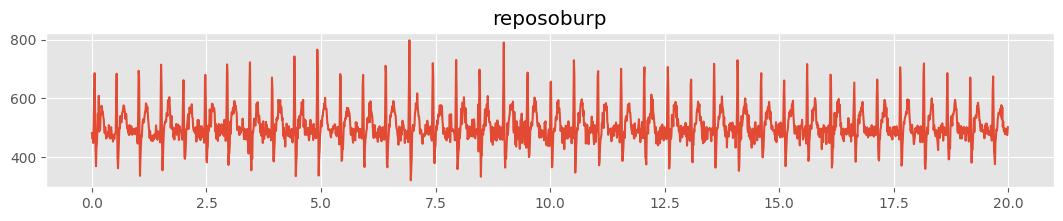

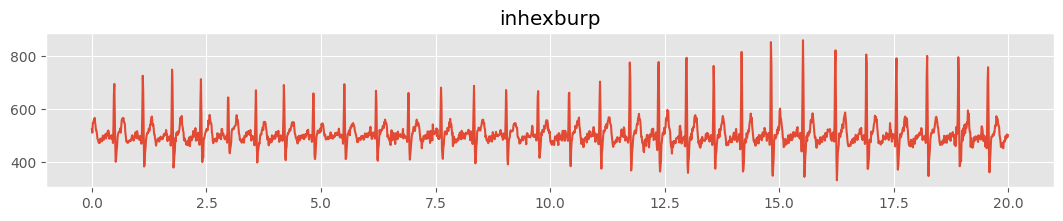

In [6]:
Fs = 100 #Frecuencia de muestreo del dispositivo de adquisición

#Ploteamos las señales en el tiempo
def plotear(array:np.ndarray,title:str,Fs:int=Fs):
    Ts=1/Fs
    n = np.arange(0,array.shape[0])  # t = n*Ts
    t = n*Ts
    plt.figure(figsize=(13,2))
    plt.title(title)
    plt.plot(t, array)

plotear(basal1,"basal1")
plotear(inhex5s,"inhex5s")
plotear(basal2,"basal2")
plotear(reposoburp,"reposoburp")
plotear(inhexburp,"inhexburp")

## Pasando a data tabular estilo Sklearn

In [7]:
def deefe(array:np.ndarray,ntarget:int,col:int=100,Fs:int=Fs) -> tuple[np.ndarray, np.ndarray]:
  Ts=1/Fs
  n = np.arange(0,array.shape[0])  # t = n*Ts
  t = n*Ts

  #Pasamos las observaciones a filas correspondientes a una variable t y d_sensor
  st_sensor = np.concatenate((t.reshape(-1,1),  array.reshape(-1,1)), axis=1)
  #Creamos el data frame con las varibles t y d_sensor
  df = pd.DataFrame(st_sensor, columns=["t","d_sensor"])
  df.head()
  #Establecemos t como index 
  df = df.set_index("t")

  d_obs = df[["d_sensor"]].values.reshape(int(array.shape[0]/col),col)
  target = np.repeat(ntarget, d_obs.shape[0])
  return d_obs,target

obs_basal1,target_basal1=deefe(basal1,0)
obs_inhex5s,target_inhex5s=deefe(inhex5s,1)
obs_basal2,target_basal2=deefe(basal2,2)

obs_reposoburp,target_reposoburp=deefe(reposoburp,3)
obs_inhexburp,target_inhexburp=deefe(inhexburp,4)

## Descripción de categoria de los ejercicios realizado en la clase de ECG

| Descripción | Categoría |
|----------|----------|
|Basal 1        |0|
|Post-ejercicio |1|
|Basal 2        |2|
|Reposo 1       |3|
|Reposo 2       |4|

* **Basal 1:** Primera medición en reposo basal.
* **Post-ejercicio:** Ciclo de repeticiones de inhalación y exhalación, con un aguante de 5 segundos por proceso.
* **Basal 2:** Segunda medición en reposo basal.
* **Reposo 1:** Medición del reposo inmediatamente después del ejercicio de alta exigencia.
* **Reposo 2:** Medición del reposo 3 mintos después del ejercicio de alta exigencia.

In [8]:
ecg = {"base": np.concatenate([obs_basal1,obs_inhex5s,obs_basal2,obs_reposoburp,obs_inhexburp]), "target": [target_basal1,target_inhex5s,target_basal2,target_reposoburp,target_inhexburp]}
ecg

{'base': array([[458., 445., 439., ..., 450., 450., 457.],
        [462., 460., 472., ..., 495., 498., 499.],
        [501., 498., 504., ..., 507., 510., 510.],
        ...,
        [475., 515., 504., ..., 484., 498., 492.],
        [487., 502., 497., ..., 403., 471., 519.],
        [480., 493., 528., ..., 504., 493., 502.]]),
 'target': [array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
  array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
  array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2]),
  array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]),
  array([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4])]}